## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import sys


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


### 2. Data Preparation and EDA

In [2]:
sys.path.append(os.path.abspath('../src/'))

In [3]:
from data_loader import load_data

# Load the Brent oil price data
data = load_data("../data/BrentOilPrices.csv")
data["Date"] = pd.to_datetime(data["Date"], format="%d-%b-%y", errors="coerce")

In [4]:
# Remove any rows with missing or invalid dates
data = data.dropna(subset=["Date"])
data = data.sort_values("Date")
prices = data["Price"].values
dates = data["Date"].values
n_points = len(prices)

#Convert prices to log returns to stabilize variance (optional, but often useful)
log_prices = np.log(prices)

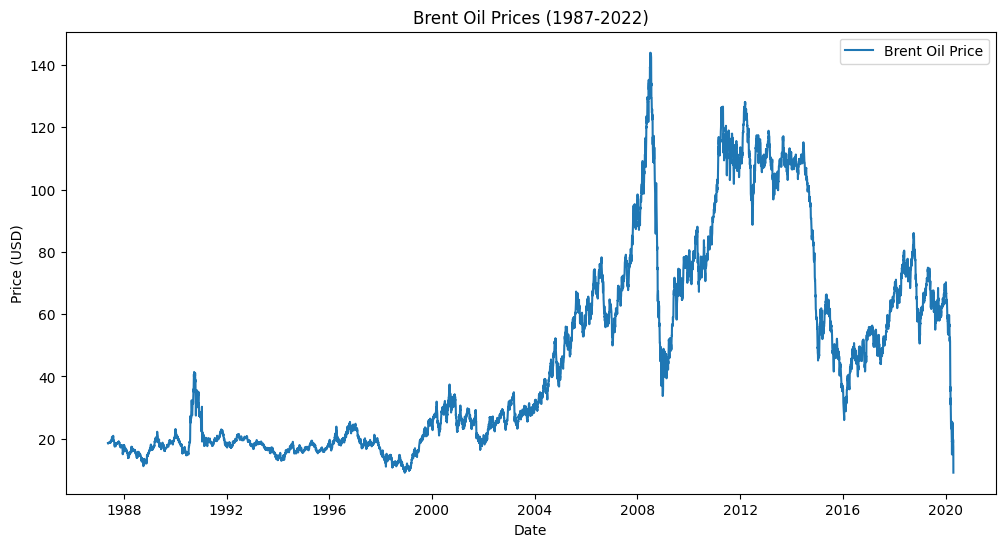

In [5]:
# Plot raw price series for EDA
plt.figure(figsize=(12, 6))
plt.plot(dates, prices, label="Brent Oil Price")
plt.title("Brent Oil Prices (1987-2022)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

## 3. Building the Bayesian Change Point Model

In [6]:
# Assuming prices and n_points are defined
price_mean = np.mean(prices)
price_std = np.std(prices)

import time
start_time = time.time()
with pm.Model() as model:
    tau1 = pm.Uniform("tau1", lower=0, upper=n_points // 2)
    tau2 = pm.Uniform("tau2", lower=tau1, upper=n_points - 1)
    mu_1 = pm.Normal("mu_1", mu=price_mean, sigma=price_std)
    mu_2 = pm.Normal("mu_2", mu=price_mean, sigma=price_std)
    mu_3 = pm.Normal("mu_3", mu=price_mean, sigma=price_std)
    sigma = pm.HalfNormal("sigma", sigma=price_std)
    idx = np.arange(n_points)
    weight1 = pm.math.sigmoid((idx - tau1) * 10)
    weight2 = pm.math.sigmoid((idx - tau2) * 10)
    mu = mu_1 * (1 - weight1) + mu_2 * weight1 * (1 - weight2) + mu_3 * weight2
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=prices)
    trace = pm.sample(100, tune=50, chains=1, cores=1, return_inferencedata=True)
print(f"Runtime: {time.time() - start_time:.2f} seconds")

Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:954: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sequential sampling (1 chains in 1 job)
INFO:pymc.sampling.mcmc:Sequential sampling (1 chains in 1 job)
NUTS: [tau1, tau2, mu_1, mu_2, mu_3, sigma]
INFO:pymc.sampling.mcmc:NUTS: [tau1, tau2, mu_1, mu_2, mu_3, sigma]


Output()

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\elemwise.py:710: 
RuntimeWarning: overflow encountered in square
  variables = ufunc(*ufunc_args, **ufunc_kwargs)

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\numpy\_core\fromnumeric.py:86: 
RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\elemwise.py:710: 
RuntimeWarning: overflow encountered in impl (vectorized)
  variables = ufunc(*ufunc_args, **ufunc_kwargs)

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\elemwise.py:710: 
RuntimeWarning: invalid value encountered in impl (vectorized)
  variables = ufunc(*ufunc_args, **ufunc_kwargs)

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\elemwise.py:710: 
RuntimeWarning: overflow encountered in exp
  variables = ufunc(*ufunc_args, **ufunc_kwargs)

c:\Users\ASTU-PG\timeseries-statistical-modeling\.timenv\Lib\site-packages\pytensor\tensor\elemwise.py:710: 
RuntimeWarning: invalid value encountered in multiply
  variables = ufunc(*ufunc_args, **ufunc_kwargs)

Sampling 1 chain for 50 tune and 100 draw iterations (50 + 100 draws total) took 3337 seconds.
INFO:pymc.sampling.mcmc:Sampling 1 chain for 50 tune and 100 draw iterations (50 + 100 draws total) took 3337 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
INFO:pymc.stats.convergence:Only one chain was sampled, this makes it impossible to run some convergence checks


Runtime: 3343.97 seconds


## 3: Interpreting the Model Output

### 3.1. Check convergence

arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


           mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
mu_1     45.726   0.087    45.566     45.891      0.057    0.018       2.0   
mu_2     37.608   1.773    34.984     40.105      1.616    0.245       1.0   
mu_3     56.905   2.074    54.024     60.243      1.878    0.308       1.0   
tau1    128.220  47.185    58.470    190.752     42.468    6.083       1.0   
tau2   4516.150  10.660  4493.371   4533.544      1.160    1.000      92.0   
sigma    25.166   1.391    22.930     27.273      1.251    0.202       1.0   

       ess_tail  r_hat  
mu_1       18.0    NaN  
mu_2       13.0    NaN  
mu_3       13.0    NaN  
tau1       15.0    NaN  
tau2       77.0    NaN  
sigma      13.0    NaN  


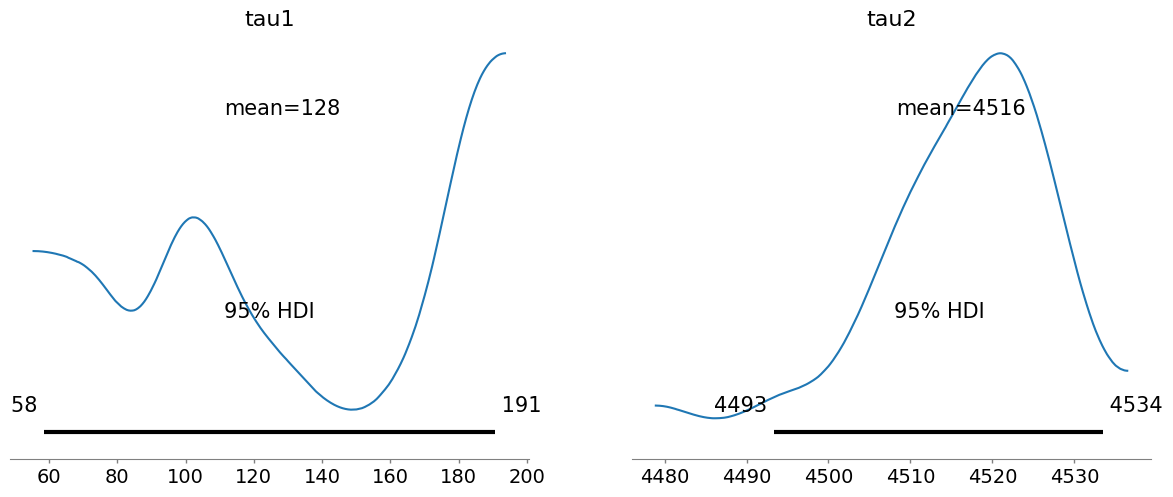

Change Point 1: 1987-11-17T00:00:00.000000000
Change Point 2: 2005-02-17T00:00:00.000000000
Regime 1 Mean Price: $45.73
Regime 2 Mean Price: $37.61
Regime 3 Mean Price: $56.90


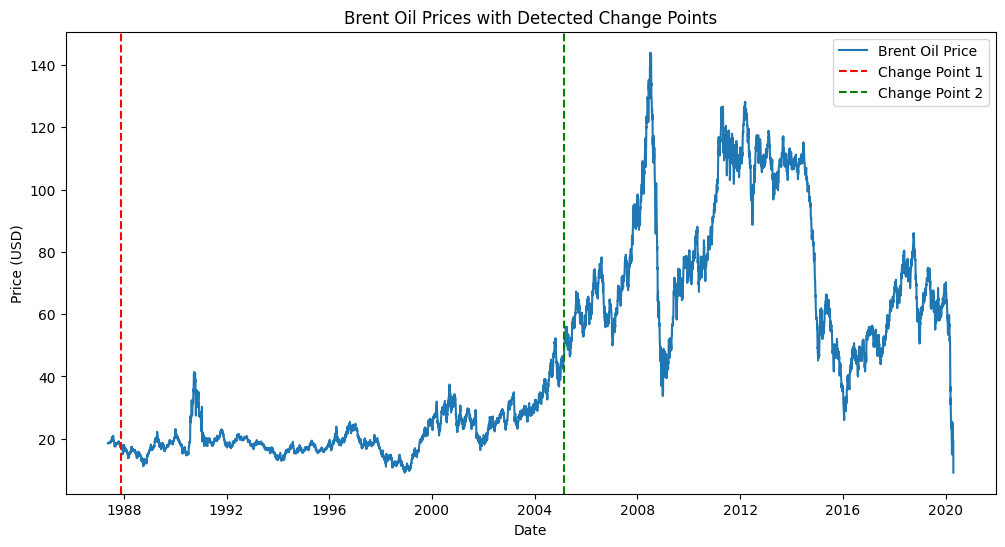

In [7]:
# Check convergence
summary = az.summary(trace, hdi_prob=0.95)
print(summary)  # Check r_hat values (should be close to 1.0)

# Plot posterior distributions of change points
az.plot_posterior(trace, var_names=["tau1", "tau2"], hdi_prob=0.95)
plt.show()

# Convert tau indices to dates
tau1_mean = int(np.mean(trace.posterior["tau1"].values))
tau2_mean = int(np.mean(trace.posterior["tau2"].values))
change_point_date1 = dates[tau1_mean]
change_point_date2 = dates[tau2_mean]
print(f"Change Point 1: {change_point_date1}")
print(f"Change Point 2: {change_point_date2}")

# Quantify impact: Extract mean prices for regimes
mu_1_mean = np.mean(trace.posterior["mu_1"].values)
mu_2_mean = np.mean(trace.posterior["mu_2"].values)
mu_3_mean = np.mean(trace.posterior["mu_3"].values)
print(f"Regime 1 Mean Price: ${mu_1_mean:.2f}")
print(f"Regime 2 Mean Price: ${mu_2_mean:.2f}")
print(f"Regime 3 Mean Price: ${mu_3_mean:.2f}")

# Plot price series with change points
plt.figure(figsize=(12, 6))
plt.plot(dates, prices, label="Brent Oil Price")
plt.axvline(change_point_date1, color="red", linestyle="--", label="Change Point 1")
plt.axvline(change_point_date2, color="green", linestyle="--", label="Change Point 2")
plt.title("Brent Oil Prices with Detected Change Points")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

### 3.2: Associate Change Points with Events

In [8]:
events = pd.DataFrame({
    "date": ["1990-08-01", "2008-01-01", "2020-03-01", "2022-02-01"],
    "event": ["Iraqi Invasion of Kuwait", "Financial Crisis", "COVID-19/Price War", "Russian Invasion of Ukraine"]
})
events["date"] = pd.to_datetime(events["date"])

# Compare change points with events
for tau_date in [change_point_date1, change_point_date2]:
    closest_event = events.iloc[((events["date"] - tau_date).abs()).argmin()]
    print(f"Change Point {tau_date}: Closest Event - {closest_event['event']} on {closest_event['date']}")

Change Point 1987-11-17T00:00:00.000000000: Closest Event - Iraqi Invasion of Kuwait on 1990-08-01 00:00:00
Change Point 2005-02-17T00:00:00.000000000: Closest Event - Financial Crisis on 2008-01-01 00:00:00


### 3.3: Quantify Impact for Reporting

In [9]:

# For each change point, calculate mean prices before/after using data slices
for tau, tau_date in [(tau1_mean, change_point_date1), (tau2_mean, change_point_date2)]:
    before = prices[max(0, tau-100):tau].mean()
    after = prices[tau:min(n_points, tau+100)].mean()
    percent_change = ((after - before) / before) * 100
    print(f"Change at {tau_date}: Price shifted from ${before:.2f} to ${after:.2f}, {percent_change:.2f}% change")

Change at 1987-11-17T00:00:00.000000000: Price shifted from $18.87 to $16.17, -14.32% change
Change at 2005-02-17T00:00:00.000000000: Price shifted from $44.16 to $51.94, 17.61% change
